# 01 — Data Exploration
This notebook loads an anonymised WhatsApp export, runs the parsing and cleaning
pipeline step by step, and visualises the results.

> **Privacy**: only synthetic / anonymised data is used. No real names or phone numbers.

## 0 · Setup

In [1]:
import os, sys
from pathlib import Path

# Notebook lives in notebooks/ → project root is one level up
PROJECT_ROOT = Path(os.getcwd()).parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\Pro\Documents\ENSAE\AS3-MOI\AS3-2025-2026\Webscrapping\Projet_final\whatsapp-analyzer


## 1 · Synthetic data — anonymised export

In [2]:
import tempfile, textwrap

# Synthetic iOS-format WhatsApp export — no real data
SYNTHETIC_CHAT = textwrap.dedent("""
[01/01/2024, 08:00:00] Aminata: Bonjour tout le monde !
[01/01/2024, 08:01:00] Moussa: Salut Aminata, ça va ?
[01/01/2024, 08:02:00] Fatou: Bonjour bonjour !
[01/01/2024, 08:05:00] Ibrahima: Quelqu'un a vu le rapport d'aujourd'hui ?
[01/01/2024, 08:06:00] Aminata: Oui je l'ai reçu ce matin, très intéressant.
[01/01/2024, 08:07:00] Moussa: <Media omitted>
[01/01/2024, 08:08:00] Fatou: Merci pour le partage Moussa !
[01/01/2024, 09:00:00] Mariama: Bonjour à tous, réunion à 14h aujourd'hui.
[01/01/2024, 09:01:00] Ibrahima: Noté, je serai là.
[01/01/2024, 09:02:00] Aminata: Parfait, à tout à l'heure.
[01/01/2024, 10:00:00] Moussa: Le projet avance bien, bonne nouvelle !
[01/01/2024, 10:01:00] Fatou: Super nouvelle, continuons comme ça.
[01/01/2024, 10:02:00] Mariama: Bravo à toute l'équipe !
[02/01/2024, 08:00:00] Ibrahima: Bonne journée à tous.
[02/01/2024, 08:05:00] Aminata: Bonne journée Ibrahima !
[02/01/2024, 09:00:00] Moussa: La réunion d'hier s'est bien passée.
[02/01/2024, 09:05:00] Fatou: Oui, très productive !
[02/01/2024, 10:00:00] Mariama: On continue le travail aujourd'hui.
""").strip()

# Write to a temporary file (never committed)
_tmp = tempfile.NamedTemporaryFile(mode="w", suffix=".txt",
                                    encoding="utf-8", delete=False)
_tmp.write(SYNTHETIC_CHAT)
_tmp.flush()
CHAT_PATH = Path(_tmp.name)
print("Temp chat file:", CHAT_PATH)

Temp chat file: C:\Users\Pro\AppData\Local\Temp\tmppslwzkvu.txt


## 2 · Step 1 — Parse

In [3]:
from whatsapp_analyzer.parser import Parser

parser = Parser(anonymize=False, group_name="SyntheticGroup")
df_raw = parser.parse(CHAT_PATH)

print(f"Parsed {len(df_raw)} messages from {df_raw['author'].nunique()} authors")
print(f"Date range: {df_raw['timestamp'].min().date()} → {df_raw['timestamp'].max().date()}")
df_raw.head(10)

Parsed 18 messages from 5 authors
Date range: 2024-01-01 → 2024-01-02


,timestamp,author,message,msg_type,group_name
0,2024-01-01 08:00:00,Aminata,Bonjour tout le monde !,text,SyntheticGroup
1,2024-01-01 08:01:00,Moussa,"Salut Aminata, ça va ?",text,SyntheticGroup
2,2024-01-01 08:02:00,Fatou,Bonjour bonjour !,text,SyntheticGroup
3,2024-01-01 08:05:00,Ibrahima,Quelqu'un a vu le rapport d'aujourd'hui ?,text,SyntheticGroup
4,2024-01-01 08:06:00,Aminata,"Oui je l'ai reçu ce matin, très intéressant.",text,SyntheticGroup
5,2024-01-01 08:07:00,Moussa,<Media omitted>,media,SyntheticGroup
6,2024-01-01 08:08:00,Fatou,Merci pour le partage Moussa !,text,SyntheticGroup
7,2024-01-01 09:00:00,Mariama,"Bonjour à tous, réunion à 14h aujourd'hui.",text,SyntheticGroup
8,2024-01-01 09:01:00,Ibrahima,"Noté, je serai là.",text,SyntheticGroup
9,2024-01-01 09:02:00,Aminata,"Parfait, à tout à l'heure.",text,SyntheticGroup


## 3 · Raw DataFrame overview

In [4]:
print("Shape:", df_raw.shape)
print()
print("Message type distribution:")
print(df_raw["msg_type"].value_counts())
print()
print("Messages per author:")
print(df_raw.groupby("author").size().sort_values(ascending=False))

Shape: (18, 5)

Message type distribution:
msg_type
text     17
media     1
Name: count, dtype: int64

Messages per author:
author
Aminata     4
Fatou       4
Moussa      4
Ibrahima    3
Mariama     3
dtype: int64


## 4 · Step 2 — Clean

In [5]:
from whatsapp_analyzer.cleaner import Cleaner

cleaner = Cleaner(lang="fr", remove_emoji=True, min_words=2, use_lemma=False)
df_clean = cleaner.clean(df_raw)

print(f"After cleaning: {len(df_clean)} messages retained")
df_clean[["author", "message", "cleaned_message", "tokens"]].head(8)

After cleaning: 16 messages retained


,author,message,cleaned_message,tokens
0,Aminata,Bonjour tout le monde !,bonjour tout monde,"[bonjour, tout, monde]"
1,Moussa,"Salut Aminata, ça va ?",salut aminata va,"[salut, aminata, va]"
2,Fatou,Bonjour bonjour !,bonjour bonjour,"[bonjour, bonjour]"
3,Ibrahima,Quelqu'un a vu le rapport d'aujourd'hui ?,quelqu vu rapport aujourd hui,"[quelqu, vu, rapport, aujourd, hui]"
4,Aminata,"Oui je l'ai reçu ce matin, très intéressant.",oui reu matin trs intressant,"[oui, reu, matin, trs, intressant]"
5,Fatou,Merci pour le partage Moussa !,merci partage moussa,"[merci, partage, moussa]"
6,Mariama,"Bonjour à tous, réunion à 14h aujourd'hui.",bonjour tous runion 14h aujourd hui,"[bonjour, tous, runion, 14h, aujourd, hui]"
7,Aminata,"Parfait, à tout à l'heure.",parfait tout heure,"[parfait, tout, heure]"


## 5 · Step 3 — Analyse (synthetic results)

In [6]:
# core.py is not yet implemented — we build synthetic analysis results
# that mirror the expected output shape of WhatsAppAnalyzer.

import numpy as np

rng = np.random.default_rng(42)
authors = df_clean["author"].unique().tolist()
n = len(df_clean)

# Synthetic topic assignment
topic_labels = ["Travail", "Organisation", "Social"]
df_clean = df_clean.copy()
df_clean["topic_id"]    = rng.integers(0, 3, size=n)
df_clean["topic_label"] = df_clean["topic_id"].map(dict(enumerate(topic_labels)))
df_clean["sentiment_score"] = rng.uniform(-1, 1, size=n).round(2)
df_clean["sentiment_label"] = df_clean["sentiment_score"].apply(
    lambda s: "positive" if s > 0.1 else ("negative" if s < -0.1 else "neutral")
)

print("Columns after analysis:")
print(df_clean.columns.tolist())
df_clean.head(5)

Columns after analysis:
['timestamp', 'author', 'message', 'msg_type', 'group_name', 'language', 'cleaned_message', 'tokens', 'topic_id', 'topic_label', 'sentiment_score', 'sentiment_label']


,timestamp,author,message,msg_type,group_name,language,cleaned_message,tokens,topic_id,topic_label,sentiment_score,sentiment_label
0,2024-01-01 08:00:00,Aminata,Bonjour tout le monde !,text,SyntheticGroup,fr,bonjour tout monde,"[bonjour, tout, monde]",0,Travail,-0.74,negative
1,2024-01-01 08:01:00,Moussa,"Salut Aminata, ça va ?",text,SyntheticGroup,fr,salut aminata va,"[salut, aminata, va]",2,Social,-0.10,neutral
2,2024-01-01 08:02:00,Fatou,Bonjour bonjour !,text,SyntheticGroup,fr,bonjour bonjour,"[bonjour, bonjour]",1,Organisation,-0.26,negative
3,2024-01-01 08:05:00,Ibrahima,Quelqu'un a vu le rapport d'aujourd'hui ?,text,SyntheticGroup,fr,quelqu vu rapport aujourd hui,"[quelqu, vu, rapport, aujourd, hui]",1,Organisation,0.85,positive
4,2024-01-01 08:06:00,Aminata,"Oui je l'ai reçu ce matin, très intéressant.",text,SyntheticGroup,fr,oui reu matin trs intressant,"[oui, reu, matin, trs, intressant]",1,Organisation,0.29,positive


## 6 · Topic distribution chart

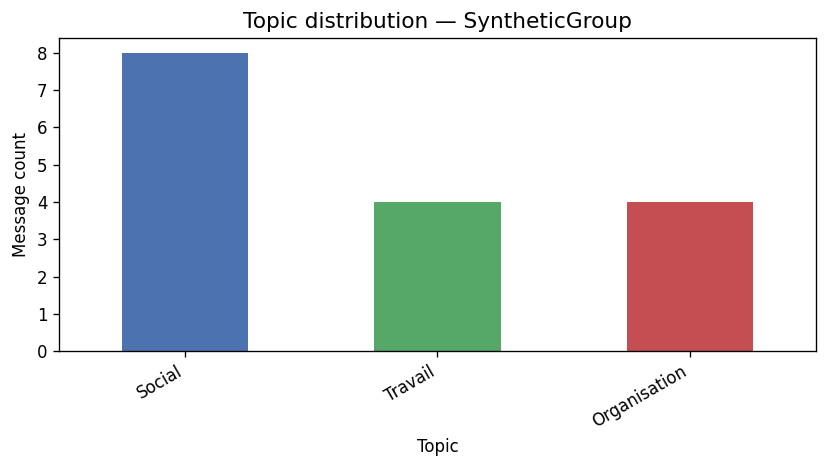

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
topic_counts = df_clean["topic_label"].value_counts()
topic_counts.plot(kind="bar", ax=ax, color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_title("Topic distribution — SyntheticGroup", fontsize=13)
ax.set_xlabel("Topic")
ax.set_ylabel("Message count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 7 · Word cloud

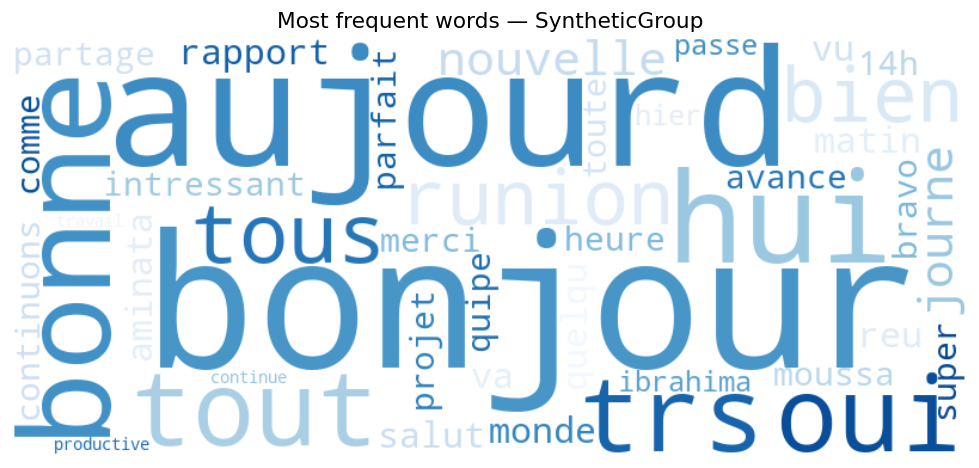

In [8]:
try:
    from wordcloud import WordCloud
    text = " ".join(df_clean["cleaned_message"].dropna())
    wc = WordCloud(width=800, height=350, background_color="white",
                   colormap="Blues", max_words=80).generate(text)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title("Most frequent words — SyntheticGroup", fontsize=13)
    plt.tight_layout()
    plt.show()
except ImportError:
    # Fallback: simple frequency bar chart
    from collections import Counter
    all_tokens = [t for tokens in df_clean["tokens"] for t in tokens]
    freq = Counter(all_tokens).most_common(15)
    words, counts = zip(*freq)
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.barh(list(words)[::-1], list(counts)[::-1], color="#4C72B0")
    ax.set_title("Top 15 words (wordcloud library not installed)", fontsize=12)
    plt.tight_layout()
    plt.show()

## 8 · Summary

In [9]:
print("=" * 50)
print("Pipeline summary")
print("=" * 50)
print(f"  Raw messages   : {len(df_raw)}")
print(f"  After cleaning : {len(df_clean)}")
print(f"  Authors        : {df_clean['author'].nunique()}")
print(f"  Topics found   : {df_clean['topic_label'].nunique()}")
print(f"  Sentiment >0   : {(df_clean['sentiment_score'] > 0).sum()} messages")
print("=" * 50)

Pipeline summary
  Raw messages   : 18
  After cleaning : 16
  Authors        : 5
  Topics found   : 3
  Sentiment >0   : 9 messages
